### Linear Regression from Scratch

#### Actions to Demonstrate:
1. Use Boston Housing Dataset
2. Initialize weights
3. Implement Cost Function (MSE)
4. Perform Gradient Descent
5. Plot loss curve
6. Compare with Sklearn.Linear Regression
7. Compute MSE, RMSE and R^2 Score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 1) Use Boston housing style dataset from local CSV
df = pd.read_csv('housing.csv')

X = df.drop(columns='MEDV').to_numpy(dtype=float)
y = df['MEDV'].to_numpy(dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize for stable gradient descent
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma = np.where(sigma == 0, 1, sigma)

X_train_std = (X_train - mu) / sigma
X_test_std = (X_test - mu) / sigma

print('Dataset shape:', df.shape)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
df.head()

Dataset shape: (489, 4)
Train shape: (391, 3) Test shape: (98, 3)


,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [3]:
# 2, 3, 4) Initialize weights, MSE cost, and gradient descent
def predict_linear(X, w, b):
    return X @ w + b

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def fit_linear_regression_gd(X, y, lr=0.01, n_iters=2000):
    n_samples, n_features = X.shape

    # Step 2: initialize parameters
    w = np.zeros(n_features)
    b = 0.0

    losses = []
    for _ in range(n_iters):
        y_pred = predict_linear(X, w, b)

        # Step 3: MSE cost
        loss = mse_loss(y, y_pred)
        losses.append(loss)

        # Gradients
        dw = (-2 / n_samples) * (X.T @ (y - y_pred))
        db = (-2 / n_samples) * np.sum(y - y_pred)

        # Step 4: update
        w -= lr * dw
        b -= lr * db

    return w, b, losses

In [4]:
w, b, losses = fit_linear_regression_gd(X_train_std, y_train, lr=0.01, n_iters=2000)

print('Initial weights:', np.zeros_like(w))
print('Learned weights :', w)
print('Learned bias    :', round(b, 4))
print('Initial loss    :', round(losses[0], 4))
print('Final loss      :', round(losses[-1], 4))

Initial weights: [0. 0. 0.]
Learned weights : [ 58790.17307144 -75604.3948364  -42110.89285296]
Learned bias    : 461758.312
Initial loss    : 241557231176.4706
Final loss      : 7949715203.5926


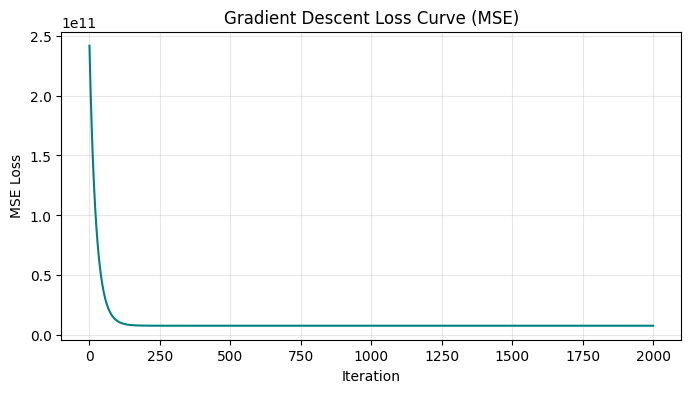

In [5]:
# 5) Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses, color='teal')
plt.title('Gradient Descent Loss Curve (MSE)')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.show()

In [6]:
# 7) Metrics for scratch model
y_pred_scratch = predict_linear(X_test_std, w, b)
scratch_mse = mean_squared_error(y_test, y_pred_scratch)
scratch_rmse = np.sqrt(scratch_mse)
scratch_r2 = r2_score(y_test, y_pred_scratch)

print('Scratch model metrics')
print(f'MSE : {scratch_mse:.4f}')
print(f'RMSE: {scratch_rmse:.4f}')
print(f'R^2 : {scratch_r2:.4f}')

Scratch model metrics
MSE : 6789025574.9005
RMSE: 82395.5434
R^2 : 0.6911


In [7]:
# 6) Compare with sklearn LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_train_std, y_train)

y_pred_sk = sk_model.predict(X_test_std)
sk_mse = mean_squared_error(y_test, y_pred_sk)
sk_rmse = np.sqrt(sk_mse)
sk_r2 = r2_score(y_test, y_pred_sk)

print('Scratch vs sklearn LinearRegression')
print(f'MSE  | Scratch: {scratch_mse:.4f} | sklearn: {sk_mse:.4f}')
print(f'RMSE | Scratch: {scratch_rmse:.4f} | sklearn: {sk_rmse:.4f}')
print(f'R^2  | Scratch: {scratch_r2:.4f} | sklearn: {sk_r2:.4f}')

Scratch vs sklearn LinearRegression
MSE  | Scratch: 6789025574.9005 | sklearn: 6789025559.2659
RMSE | Scratch: 82395.5434 | sklearn: 82395.5433
R^2  | Scratch: 0.6911 | sklearn: 0.6911


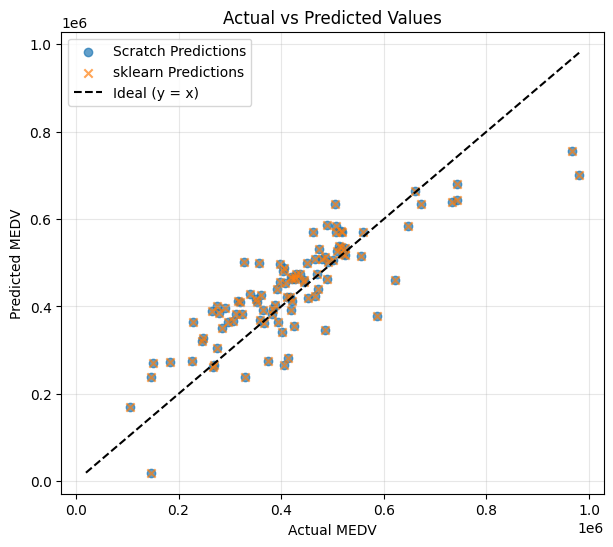

In [8]:
# Visualize actual vs predicted values
min_val = min(y_test.min(), y_pred_scratch.min(), y_pred_sk.min())
max_val = max(y_test.max(), y_pred_scratch.max(), y_pred_sk.max())

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_scratch, alpha=0.7, label='Scratch Predictions')
plt.scatter(y_test, y_pred_sk, alpha=0.7, marker='x', label='sklearn Predictions')
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal (y = x)')
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
w_raw, b_raw, losses_raw = fit_linear_regression_gd(X_train, y_train, lr=1e-6, n_iters=2000)
y_pred_raw = predict_linear(X_test, w_raw, b_raw)

if not np.isfinite(y_pred_raw).all():
    raise ValueError('Raw-feature training diverged (non-finite predictions). Reduce lr further, e.g., 1e-7.')

raw_mse = mean_squared_error(y_test, y_pred_raw)
raw_rmse = np.sqrt(raw_mse)
raw_r2 = r2_score(y_test, y_pred_raw)

print('Without standardization (smaller lr, same iterations):')
print(f'MSE : {raw_mse:.4f}')
print(f'RMSE: {raw_rmse:.4f}')
print(f'R^2 : {raw_r2:.4f}')
print(f'Final MSE Loss (scaled): {losses[-1]:.4f}')
print(f'Final MSE Loss (raw)   : {losses_raw[-1]:.4f}')

Without standardization (smaller lr, same iterations):
MSE : 38674785527.0195
RMSE: 196659.0591
R^2 : -0.7597
Final MSE Loss (scaled): 7949715203.5926
Final MSE Loss (raw)   : 54613044061.3929
